In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 基于python求解单层感知器算法
里面get_update函数其实就是用的 https://www.yuque.com/feifei-z1hpi/acw30f/zeg4yhrsikk86g8t
里的单层感知器求解里的公式

迭代次数： 13


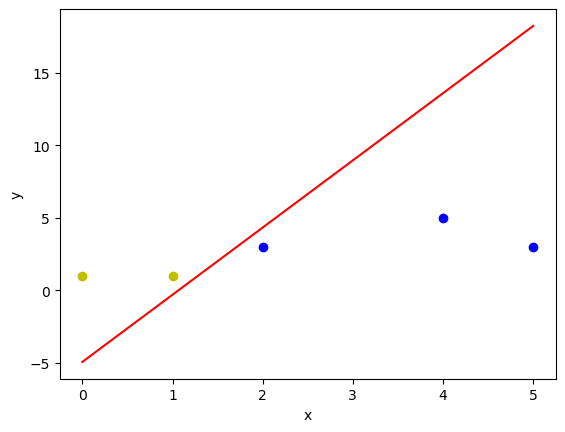

In [3]:
n = 0 # 迭代次数
lr = 0.1 # 学习率

# 输入数据，三个维度分别表示偏置、x坐标，y坐标
X = np.array([[1, 2, 3],
              [1, 4, 5],
              [1, 1, 1],
              [1, 5, 3],
              [1, 0, 1]])

# 标签
Y = np.array([1, 1, -1, 1, -1])

# 要学习的模型，f(wx + B)，对于正样本，f(wx + b) > 0，对于负样本，f(wx = b) < 0

# 权重w初始化，取值范围-1到1
# X.shape[1]  获取输入矩阵 X 的列数（特征维度），X 是 5×3 的矩阵，所以 X.shape[1] = 3
# np.random.random(3) 生成 3 个在 [0, 1) 区间的随机浮点数
W = (np.random.random(X.shape[1]) - 0.5) * 2

# 可视化函数
def get_show():
  # 正样本
  all_positive_x = [2, 4, 5]
  all_positive_y = [3, 5, 3]
  # 负样本
  all_negative_x = [1, 0]
  all_negative_y = [1, 1]

  # 计算分界线斜率与截距，W[0] + W[1]*x + W[2]*y = 0 转换成 y = kx + b的形式
  k = -W[1] / W[2]
  b = -W[0] / W[2]

  # 生成x刻度
  # np.linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None) 用于生成等间距数值序列的函数
  xdata = np.linspace(0, 5)
  plt.figure()
  plt.plot(xdata, k * xdata + b, c='r')
  plt.plot(all_positive_x, all_positive_y, 'bo')
  plt.plot(all_negative_x, all_negative_y, 'yo')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.show()
  
# 更新权重值函数
# 实际就是梯度反向传播算法
def get_update():
  # 定义所有全局变量
  global X, Y, W, lr, n
  n += 1
  # 计算符号函数输出
  new_output = np.sign(np.dot(X, W.T))
  # 更新权重值
  new_W = W + lr * (Y - new_output.T).dot(X)
  # 更新权重值
  W = new_W

def main():
  for _ in range(100):
    get_update()
    new_output = np.sign(np.dot(X, W.T))
    if(new_output == Y.T).all():
      print('迭代次数：', n)
      break
  get_show()
  
main()

# 基于python求解多层感知器算法

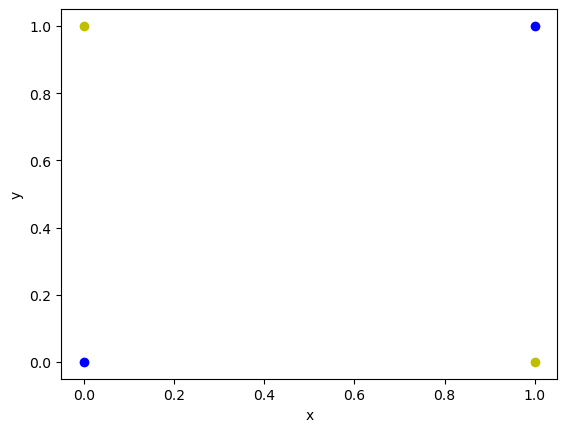

ValueError: shapes (4,4) and (1,4) not aligned: 4 (dim 1) != 1 (dim 0)

In [2]:
# 输入数据
X = np.array([[1, 0, 0],
              [1, 0, 1],
              [1, 1, 0],
              [1, 1, 1]])

# 标签
Y = np.array([0, 1, 1, 0])

# 权重w初始化，取值范围-1到1
# 第一个网络层参数矩阵
V = (np.random.random((3, 4)) - 0.5) * 2
# 第二个网络层参数矩阵
W = (np.random.random((4, 1)) - 0.5) * 2

def get_show():
  # 正样本
  all_positive_x = [0, 1]
  all_positive_y = [0, 1]
  # 负样本
  all_negative_x = [0, 1]
  all_negative_y = [1, 0]
  
  plt.figure()
  plt.plot(all_positive_x, all_positive_y, 'bo')
  plt.plot(all_negative_x, all_negative_y, 'yo')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.show()
  
get_show()
  
lr = 0.11

# 激活函数（从0～1）
def sigmoid(x):
  x = 1 / (1 + np.exp(-x))
  return x

# 激活函数（从0～1）的导数
# 激活函数的导数，f'(x)=f(x)(1-f(x)),dsigmoid(x)=sigmoid(x)*(1-sigmoid(x))
def sigmoid_derivative(x):
  x = x * (1 - x)
  return x

# 更新权重值(2个权值矩阵，V和W)
def update():
  global X, Y, V, W, lr
  L1 = sigmoid(np.dot(X, V)) # 隐藏层输出(4 * 3) * (3 * 4) = (4, 4)
  L2 = sigmoid(np.dot(L1, W)) # 输出层输出(4, 4) * (4, 1) = (4, 1)
  L2_delta = (Y.T - L2) * sigmoid_derivative(L2) # 输出层误差 = 下一层的误差 * 激活函数导数 * 与下一层的连接权重矩阵（全为1）
  L1_delta = L2_delta.dot(W.T) * sigmoid_derivative(L1) # 隐藏层的误差 = 下一层的误差 * 激活函数导数 * 与下一层的连接权重矩阵
  W_C = lr * L1.T.dot(L2_delta) # 更新W(4, 1)
  V_C = lr * X.T.dot(L1_delta) # 更新V(3, 4)
  W = W + W_C
  V = V + V_C
  
errors = [] # 记录误差
for i in range(100000):
  update() # 更新权值
  if i % 1000 == 0: # 每1000次记录一次误差
    L1 = sigmoid(np.dot(X, V)) # 隐藏层输出(4 * 3) * (3 * 4) = (4, 4)
    L2 = sigmoid(np.dot(L1, W)) # 输出层输出(4, 4) * (4, 1) = (4, 1)
    errors.append(np.mean(np.abs(Y.T - L2)))
    print('Errors:', np.mean(np.abs(Y.T - L2)))

plt.plot(errors)
plt.ylabel('errors')
plt.show()

L1 = sigmoid(np.dot(X, V)) # 隐藏层输出(4*3)*(3*4)=(4, 4)
L2 = sigmoid(np.dot(L1, W)) # 输出层输出(4, 4)*(4, 1)=(4, 1)
print(L2)

def classify(x):
  if x > 0.5:
    return 1
  else:
    return 0
    
for i in map(classify, L2): # L2 一共4个数
  print(i)
